## Performance comparison of triangular matrix inverse

> The goal is to understand the "peak performance" of Ascend for AIV / AIC triangular inverse methods.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'inverse_type', "style":'inverse_type', "markers":_MARKERS, "dashes":True}


In [2]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
chunk_size = 128

In [3]:
def add_stats_siso(df, nbytes_out_dtype: int):
    df["size"] = df["numel"]
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [4]:
PREFIX_PATH = "../.."

df = pd.read_csv(f"{PREFIX_PATH}/bench_results_solve_tril_{chunk_size}.csv")
add_stats_siso(df, 2)

T, H, D = df["T"].unique()[0], df["H"].unique()[0], df["D"].unique()[0]

In [5]:
df.head()

,inverse_type,dtype,B,T,H,D,numel,chunk_size,time_us,size,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,torch_eager,fp16,2,500,4,32,524288,128,5770,524288,2,2097152,0.090864,0.363458
1,torch_eager,fp16,5,500,4,32,1310720,128,8979,1310720,2,5242880,0.145976,0.583905
2,torch_eager,fp16,10,500,4,32,2621440,128,11252,2621440,2,10485760,0.232975,0.931902
3,torch_eager,fp16,15,500,4,32,3932160,128,13588,3932160,2,15728640,0.289385,1.157539
4,torch_eager,fp16,20,500,4,32,5242880,128,15798,5242880,2,20971520,0.331870,1.327479


## Paper plots

/tmp/ipykernel_3909511/850792411.py:8: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


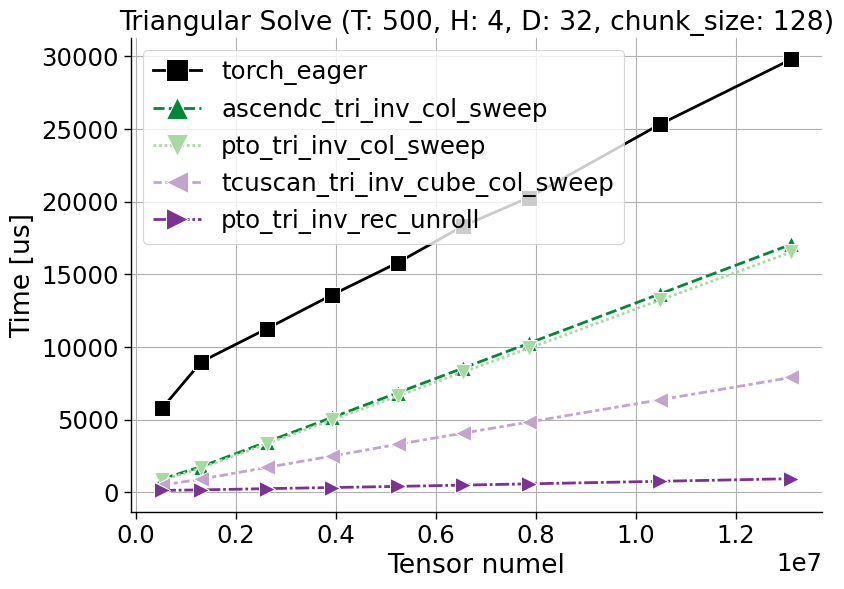

<Figure size 870x627 with 0 Axes>

In [6]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Triangular Solve (T: {T}, H: {H}, D: {D}, chunk_size: {chunk_size})")
ax.set_xlabel("Tensor numel")
ax.set_ylabel("Time [us]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/tri_inv_time_us.png")
plt.show()
plt.clf()


/tmp/ipykernel_3909511/2632021592.py:8: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


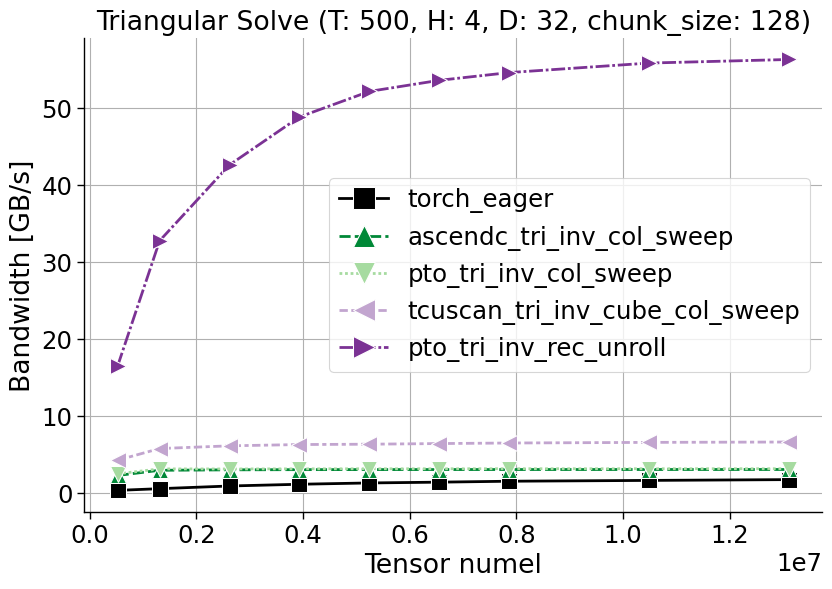

<Figure size 870x627 with 0 Axes>

In [7]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Triangular Solve (T: {T}, H: {H}, D: {D}, chunk_size: {chunk_size})")
ax.set_xlabel("Tensor numel")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/tri_inv_bw_gbps.png")
plt.show()
plt.clf()